In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
rel_path = "challenge_material"
df = pd.read_csv(os.path.join(rel_path, "customers_sales.csv"))

In [3]:
df.head()

,customer_name,customer_branch,file_name,order_quantity
0,MetalForm SA,Frankfurt Branch,Geo (1).DXF,4900
1,PrecisionCut GmbH,Stuttgart Branch,Geo (10).DXF,6964
2,PrecisionCut GmbH,Stuttgart Branch,Geo (11).DXF,4107
3,MetalForm SA,Frankfurt Branch,Geo (12).DXF,5695
4,AutoParts AG,Berlin Branch,Geo (13).DXF,8027


In [4]:
df.shape

(80, 4)

In [5]:
df.dtypes

customer_name      object
customer_branch    object
file_name          object
order_quantity      int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_name    80 non-null     object
 1   customer_branch  80 non-null     object
 2   file_name        80 non-null     object
 3   order_quantity   80 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.6+ KB


In [7]:
print(df.isnull().sum())

customer_name      0
customer_branch    0
file_name          0
order_quantity     0
dtype: int64


In [8]:
df.describe()

,order_quantity
count,80.00000
mean,6984.92500
std,1959.10825
min,2187.00000
25%,5563.25000
50%,7734.00000
75%,8466.75000
max,9808.00000


Fixing the typo

In [20]:
df['customer_name'] = df['customer_name'].replace('AutoPart AG', 'AutoParts AG')

Finding the missing values and adding them as TechFab Industries, Hamburg Branch, 2000.

In [21]:
def fix_missing(df):
    files = os.listdir('challenge_material\\10991360')

    existing_files = df['file_name'].dropna().unique()
    missing_files = [f for f in files if f not in existing_files]

    print(f"Missing files: {len(missing_files)}")
    return missing_files

missing = fix_missing(df)

def add_missing(df, missing, customer_name, customer_branch, order_quantity):
    if len(missing) == 0:
        return df

    new_rows = pd.DataFrame({
        'file_name': missing,
        'customer_name': [customer_name] * len(missing),
        'customer_branch': [customer_branch] * len(missing),
        'order_quantity': [order_quantity] * len(missing)
    })

    return pd.concat([df, new_rows], ignore_index=True)

df = add_missing(df, missing, 'TechFab Industries', 'Hamburg Branch', 2000)

Missing files: 5


In [22]:
def branchPerCustomer(df):
    return df.groupby('customer_name')['customer_branch'].value_counts()
branchPerCustomer(df)

customer_name       customer_branch 
AutoParts AG        Munich Branch       26
                    Berlin Branch       19
MetalForm SA        Frankfurt Branch    15
PrecisionCut GmbH   Stuttgart Branch    17
TechFab Industries  Hamburg Branch       8
Name: count, dtype: int64

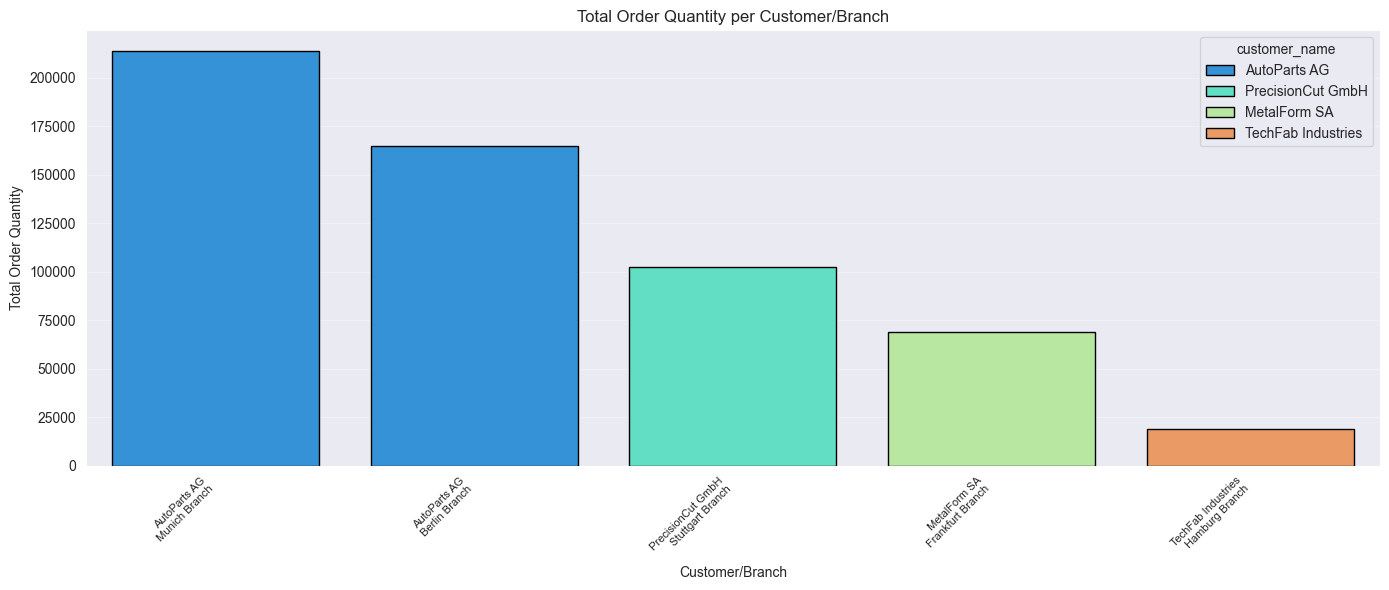

,customer_name,customer_branch,order_quantity,customer_branch_label
1,AutoParts AG,Munich Branch,213708,AutoParts AG\nMunich Branch
0,AutoParts AG,Berlin Branch,164870,AutoParts AG\nBerlin Branch
3,PrecisionCut GmbH,Stuttgart Branch,102346,PrecisionCut GmbH\nStuttgart Branch
2,MetalForm SA,Frankfurt Branch,68871,MetalForm SA\nFrankfurt Branch
4,TechFab Industries,Hamburg Branch,18999,TechFab Industries\nHamburg Branch


In [24]:
def customerPerQuantity(df):
    # Sum of order_quantity per customer per branch
    branch_totals = df.groupby(['customer_name', 'customer_branch'])['order_quantity'].sum().reset_index()

    # Sort by values for better visualization
    branch_totals = branch_totals.sort_values('order_quantity', ascending=False)

    # Create customer-branch label
    branch_totals['customer_branch_label'] = branch_totals['customer_name'] + '\n' + branch_totals['customer_branch']

    # Create bar plot with seaborn
    plt.figure(figsize=(14, 6))
    sns.barplot(data=branch_totals, x='customer_branch_label', y='order_quantity',
                hue='customer_name', palette='rainbow', edgecolor='black', linewidth=1)
    plt.xlabel('Customer/Branch')
    plt.ylabel('Total Order Quantity')
    plt.title('Total Order Quantity per Customer/Branch')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return branch_totals


customerPerQuantity(df)